### **Objective**
 <i>Design and implement an advanced automated framework for the early and accurate diagnosis of dementia through MRI brain image analysis. This involves the systematic collection and preparation of datasets containing both healthy and demented cases, application of preprocessing techniques such as noise removal, skull stripping, and edge enhancement to improve image quality, segmentation of the White Matter (WM) region for precise identification of dementia-related abnormalities, and classification of images into four diagnostic categories: **Non-Demented (ND), Very Mild Demented (VMD), Mild Demented (MD), and Moderately Demented (MOD)**. The project further aims to train and optimize the InceptionV3 Convolutional Neural Network (CNN) architecture for robust classification, while rigorously evaluating model performance using standard metrics including Accuracy, Precision, Recall, F1-Score, and Loss value. Ultimately, the study seeks to demonstrate the effectiveness of the proposed system in supporting medical professionals with reliable, efficient, and clinically valuable decision-making in dementia diagnosis.<i>

### **Import Libraries**

In [ ]:
# !pip install numpy pandas seaborn matplotlib Pillow imbalanced-learn
# !pip install scikit-learn tensorflow tensorflow-addons pydot graphviz scikit-image

In [1]:
# Standard Libraries
import os
import glob
from random import randint

# Numerical and Data Manipulation
import numpy as np
import pandas as pd

# Image Processing
from PIL import Image
import cv2
from skimage.io import imread

# Visualization
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras import Sequential, Input, Model
from tensorflow.keras.layers import (
    Dense, Dropout, Conv2D, SeparableConv2D, 
    BatchNormalization, GlobalAveragePooling2D, 
    Flatten, MaxPooling2D, MaxPool2D
)
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
)
from tensorflow.keras.applications.inception_v3 import InceptionV3
# from tensorflow.keras.preprocessing.image import ImageDataGenerator, image
from tensorflow.keras.preprocessing.image import ImageDataGenerator as IDG
# File Utilities
from distutils.dir_util import copy_tree, remove_tree

# Scikit-learn & Imbalanced Data Handling
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import (
    matthews_corrcoef as MCC,
    balanced_accuracy_score as BAS,
    classification_report,
    confusion_matrix
)

# Custom Modules
from image_enhancement import image_enhancement
from contrast_image import contrast_image

# Display TensorFlow Version
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [2]:
from tqdm import tqdm

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    roc_curve, 
    auc, 
    matthews_corrcoef
)

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.python.framework.ops import EagerTensor
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (
    Dense, 
    Dropout, 
    Flatten, 
    Conv2D, 
    MaxPooling2D, 
    BatchNormalization, 
    Activation, 
    Input, 
    GlobalAveragePooling2D, 
    Average, 
    Concatenate,
    Add, 
    ZeroPadding2D, 
    AveragePooling2D, 
    GlobalMaxPooling2D
)
from tensorflow.keras.applications import DenseNet169 ,DenseNet201
from tensorflow.keras.applications.resnet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.initializers import random_uniform, glorot_uniform, constant, identity
from tensorflow.keras.utils import plot_model
from tensorflow.keras.metrics import CategoricalAccuracy

# External Services
from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, RMSprop
import tensorflow as tf
from sklearn.model_selection import train_test_split
import scipy.misc

# Jupyter Settings
%matplotlib inline
np.random.seed(1)
tf.random.set_seed(2)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16328\3430242201.py:49: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  import scipy.misc


### **Test Dict Creation**

Data Set Link - https://www.kaggle.com/datasets/marcopinamonti/alzheimer-mri-4-classes-dataset/data

In [1]:
# Split the data into 80-20 for the train and test
#-------------One-time activity -------------------------------
import os
import shutil
import random
from pathlib import Path

# Set your paths
parent_dir = "Alzheimer_MRI_4_classes_dataset"  # Replace with your folder path
output_dir = "output"  # Destination for train/test split

# Create output directories
train_dir = os.path.join(output_dir, "train")
test_dir = os.path.join(output_dir, "test")
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Set the split ratio
train_ratio = 0.8

# Iterate over each class folder
for class_name in os.listdir(parent_dir):
    class_path = os.path.join(parent_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    random.shuffle(images)

    # Split
    split_idx = int(len(images) * train_ratio)
    train_images = images[:split_idx]
    test_images = images[split_idx:]

    # Create class folders in train/test directories
    train_class_dir = os.path.join(train_dir, class_name)
    test_class_dir = os.path.join(test_dir, class_name)
    os.makedirs(train_class_dir, exist_ok=True)
    os.makedirs(test_class_dir, exist_ok=True)

    # Copy files
    for img in train_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(train_class_dir, img))
    for img in test_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(test_class_dir, img))

print("Split complete.")


Split complete.


### **Data Loading**

Load the data for the Preprocessing and model building

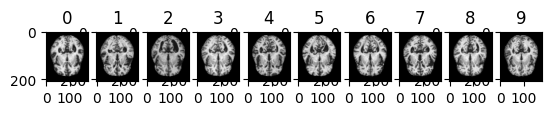

In [19]:
# TEST FOLDER
folders = glob.glob('output\\test\\MildDemented*')
imagenames_list = []
for folder in folders:
    for f in glob.glob(folder+'/*.jpg'):
        imagenames_list.append(f)

read_images_mild = []        
for image in imagenames_list:
    read_images_mild.append(cv2.imread(image))
for i in range(2):
    ax=plt.subplot(1,10,i+1)
    ax.title.set_text(i)
    plt.imshow(read_images_mild[i])    
    
# TRAIN FOLDER 
folders = glob.glob('output\\train\\MildDemented*')
imagenames_list = []
for folder in folders:
    for f in glob.glob(folder+'/*.jpg'):
        imagenames_list.append(f)

read_images_mildt = []        
for image in imagenames_list:
    read_images_mildt.append(cv2.imread(image))
for i in range(10):
    ax=plt.subplot(1,10,i+1)
    ax.title.set_text(i)
    plt.imshow(read_images_mildt[i])  

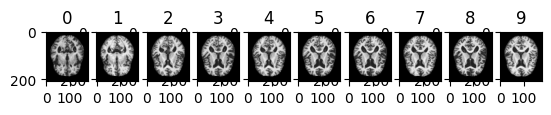

In [20]:
folders = glob.glob('output\\test\\ModerateDemented*')
imagenames_list = []
for folder in folders:
    for f in glob.glob(folder+'/*.jpg'):
        imagenames_list.append(f)

read_images_moderate = []        
for image in imagenames_list:
    read_images_moderate.append(cv2.imread(image))
for i in range(10):
    ax=plt.subplot(1,10,i+1)
    ax.title.set_text(i)
    plt.imshow(read_images_moderate[i])

# Train folder 

folders = glob.glob('output\\train\\ModerateDemented*')
imagenames_list = []
for folder in folders:
    for f in glob.glob(folder+'/*.jpg'):
        imagenames_list.append(f)

read_images_moderatet = []        
for image in imagenames_list:
    read_images_moderatet.append(cv2.imread(image))
for i in range(10):
    ax=plt.subplot(1,10,i+1)
    ax.title.set_text(i)
    plt.imshow(read_images_moderatet[i])

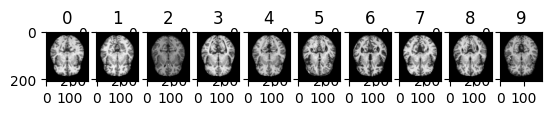

In [21]:
folders = glob.glob('output\\test\\NonDemented*')
imagenames_list = []
for folder in folders:
    for f in glob.glob(folder+'/*.jpg'):
        imagenames_list.append(f)

read_images_non = []        
for image in imagenames_list:
    read_images_non.append(cv2.imread(image))
for i in range(10):
    ax=plt.subplot(1,10,i+1)
    ax.title.set_text(i)
    plt.imshow(read_images_non[i])

# Train Folder 
folders = glob.glob('output\\train\\NonDemented*')
imagenames_list = []
for folder in folders:
    for f in glob.glob(folder+'/*.jpg'):
        imagenames_list.append(f)

read_images_nont = []        
for image in imagenames_list:
    read_images_nont.append(cv2.imread(image))
for i in range(10):
    ax=plt.subplot(1,10,i+1)
    ax.title.set_text(i)
    plt.imshow(read_images_nont[i])


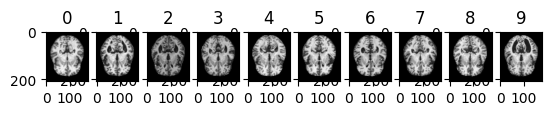

In [22]:
folders = glob.glob('output\\test\\VeryMildDemented*')
imagenames_list = []
for folder in folders:
    for f in glob.glob(folder+'/*.jpg'):
        imagenames_list.append(f)

read_images_verymild = []        
for image in imagenames_list:
    read_images_verymild.append(cv2.imread(image))
for i in range(10):
    ax=plt.subplot(1,10,i+1)
    ax.title.set_text(i)
    plt.imshow(read_images_verymild[i])
    
# Train Folder

folders = glob.glob('output\\train\\VeryMildDemented*')
imagenames_list = []
for folder in folders:
    for f in glob.glob(folder+'/*.jpg'):
        imagenames_list.append(f)

read_images_verymildt = []        
for image in imagenames_list:
    read_images_verymildt.append(cv2.imread(image))
for i in range(10):
    ax=plt.subplot(1,10,i+1)
    ax.title.set_text(i)
    plt.imshow(read_images_verymildt[i])

### **Preprocessing**

- **Noise Removal (Bilateral Filter)** → To eliminate MRI artifacts while preserving brain structures.<p>
- **Edge Enhancement (Histogram Equalization)** → To improve contrast and highlight structural differences.<p>
- **Resizing & Normalization** → To standardize all inputs for CNN training.<p>
- **Data Augmentation** → To balance the dataset across dementia classes.


#### **Bilateral Filter with Histogram Equalization - <i>Mild Demented Images<i>**

In [23]:
# -Reduces noise in an image
# -Preserves edges better than normal blurring methods (like Gaussian blur)
bilateral_mild=[]
bilateral_mildt=[]
for i in range(len(read_images_mild)):
    
    bilateral_mild.append(cv2.bilateralFilter(read_images_mild[i],15,80,80))
for i in range(len(read_images_mildt)):
    bilateral_mildt.append(cv2.bilateralFilter(read_images_mildt[i],15,80,80))

In [24]:
size=(224,224)
#resize image
out = cv2.resize(bilateral_mild[1],size)

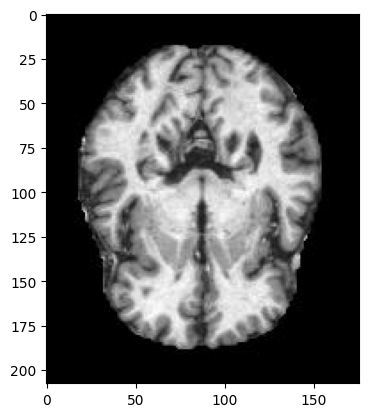

In [25]:
plt.imshow(read_images_mild[3])

In [26]:
# Image enhancement using Minimum Mean Brightness Error Bi-Histogram Equalization (MMBEBHE)
enhancement_mild=[]
enhancement_mildt=[]
for i in range(len(bilateral_mild)):
    ie = image_enhancement.IE(bilateral_mild[i], 'HSV')
    ci = contrast_image.CI(bilateral_mild[i], 'HSV')
    output = ci.MMBEBHE()
    out = cv2.resize(output,size)
    enhancement_mild.append(out)
for i in range(len(bilateral_mildt)):
    ci = contrast_image.CI(bilateral_mildt[i], 'HSV')
    ie = image_enhancement.IE(bilateral_mildt[i], 'HSV')
    output = ci.MMBEBHE()
    out = cv2.resize(output,size)
    enhancement_mildt.append(out)

In [ ]:
#-----------Step-by-step Breakdown of segmentation--------------------
# -Convert BGR to RGB
# -Reshape for k-means clustering
# -K-means clustering
# -Mask out one cluster
# -Conditional resizing and storing

#Removing background or irrelevant brain regions from MRI scans.

enhancement_mild_wm=[]
for i in range(len(read_images_mild)):
    image = cv2.cvtColor(read_images_mild[i], cv2.COLOR_BGR2RGB)
    pixel_values = image.reshape((-1, 3))
# convert to float
    pixel_values = np.float32(pixel_values)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    k = 3
    _, labels, (centers) = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    # convert back to 8 bit values
    centers = np.uint8(centers)

# flatten the labels array
    labels = labels.flatten()
# disable only the cluster number 2 (turn the pixel into black)
    masked_image = np.copy(read_images_mild[i])
# convert to the shape of a vector of pixel values
    masked_image = masked_image.reshape((-1, 3))
# color (i.e cluster) to disable
    cluster = 1
    masked_image[labels == cluster] = [0, 0, 0]
# convert back to original shape
    masked_image = masked_image.reshape(image.shape)
    #masked_image = cv2.resize(masked_image,size)
# show the image
    if masked_image.sum()>2800000:
        masked_image = cv2.resize(masked_image,size)
        enhancement_mild_wm.append(masked_image)
    else:
        img = masked_image-read_images_mild[i]
        img = cv2.resize(img,size)
        enhancement_mild_wm.append(img)

In [29]:
enhancement_mildt_wm=[]
read_images_mild  = read_images_mildt
for i in range(len(read_images_mild)):
    image = cv2.cvtColor(read_images_mild[i], cv2.COLOR_BGR2RGB)
    pixel_values = image.reshape((-1, 3))
# convert to float
    pixel_values = np.float32(pixel_values)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    k = 3
    _, labels, (centers) = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    # convert back to 8 bit values
    centers = np.uint8(centers)

# flatten the labels array
    labels = labels.flatten()
# disable only the cluster number 2 (turn the pixel into black)
    masked_image = np.copy(read_images_mild[i])
# convert to the shape of a vector of pixel values
    masked_image = masked_image.reshape((-1, 3))
# color (i.e cluster) to disable
    cluster = 1
    masked_image[labels == cluster] = [0, 0, 0]
# convert back to original shape
    masked_image = masked_image.reshape(image.shape)
    #masked_image = cv2.resize(masked_image,size)
# show the image
    if masked_image.sum()>2800000:
        masked_image = cv2.resize(masked_image,size)
        enhancement_mildt_wm.append(masked_image)
    else:
        img = masked_image-read_images_mild[i]
        img = cv2.resize(img,size)
        enhancement_mildt_wm.append(img)

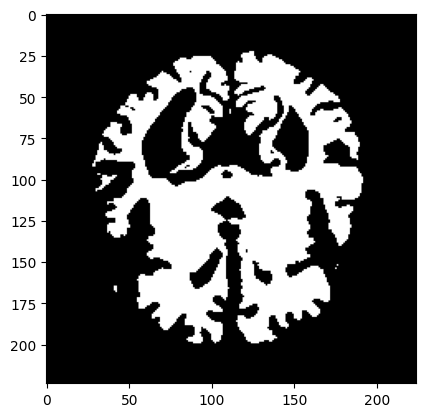

In [ ]:
# Final output of the image
ret, bw_img = cv2.threshold(enhancement_mildt_wm[12],127,255,cv2.THRESH_BINARY)
plt.imshow(bw_img)

#### **Bilateral Filter with Histogram Equalization - <i>Moderate Demented Images<i>**

In [31]:
bilateral_moderate=[]
bilateral_moderatet=[]
for i in range(len(read_images_moderate)):
    bilateral_moderate.append(cv2.bilateralFilter(read_images_moderate[i],15,80,80))
for i in range(len(read_images_moderatet)):
    bilateral_moderatet.append(cv2.bilateralFilter(read_images_moderatet[i],15,80,80))

In [32]:
enhancement_moderate=[]
enhancement_moderatet=[]
for i in range(len(bilateral_moderate)):
    ie = image_enhancement.IE(bilateral_moderate[i], 'HSV')
    ci = contrast_image.CI(bilateral_moderate[i], 'HSV')
    output = ci.MMBEBHE()
    out = cv2.resize(output,size)
    enhancement_moderate.append(out)
for i in range(len(bilateral_moderatet)):
    ci = contrast_image.CI(bilateral_moderatet[i], 'HSV')
    ie = image_enhancement.IE(bilateral_moderatet[i], 'HSV')
    output = ci.MMBEBHE()
    out = cv2.resize(output,size)
    enhancement_moderatet.append(out)

In [33]:
enhancement_moderate_wm = []
read_images_mild = read_images_moderate
for i in range(len(read_images_mild)):
    image = cv2.cvtColor(read_images_mild[i], cv2.COLOR_BGR2RGB)
    pixel_values = image.reshape((-1, 3))
# convert to float
    pixel_values = np.float32(pixel_values)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    k = 3
    _, labels, (centers) = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    # convert back to 8 bit values
    centers = np.uint8(centers)

# flatten the labels array
    labels = labels.flatten()
# disable only the cluster number 2 (turn the pixel into black)
    masked_image = np.copy(read_images_mild[i])
# convert to the shape of a vector of pixel values
    masked_image = masked_image.reshape((-1, 3))
# color (i.e cluster) to disable
    cluster = 1
    masked_image[labels == cluster] = [0, 0, 0]
# convert back to original shape
    masked_image = masked_image.reshape(image.shape)
# show the image
    if masked_image.sum()>2800000:
        masked_image = cv2.resize(masked_image,size)
        enhancement_moderate_wm.append(masked_image)
    else:
        img = masked_image-read_images_mild[i]
        img = cv2.resize(img,size)
        enhancement_moderate_wm.append(img)

In [34]:
enhancement_moderatet_wm = []
read_images_mild = read_images_moderatet
for i in range(len(read_images_mild)):
    image = cv2.cvtColor(read_images_mild[i], cv2.COLOR_BGR2RGB)
    pixel_values = image.reshape((-1, 3))
# convert to float
    pixel_values = np.float32(pixel_values)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    k = 3
    _, labels, (centers) = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    # convert back to 8 bit values
    centers = np.uint8(centers)

# flatten the labels array
    labels = labels.flatten()
# disable only the cluster number 2 (turn the pixel into black)
    masked_image = np.copy(read_images_mild[i])
# convert to the shape of a vector of pixel values
    masked_image = masked_image.reshape((-1, 3))
# color (i.e cluster) to disable
    cluster = 1
    masked_image[labels == cluster] = [0, 0, 0]
# convert back to original shape
    masked_image = masked_image.reshape(image.shape)
# show the image
    if masked_image.sum()>2800000:
        masked_image = cv2.resize(masked_image,size)
        enhancement_moderatet_wm.append(masked_image)
    else:
        img = masked_image-read_images_mild[i]
        img = cv2.resize(img,size)
        enhancement_moderatet_wm.append(img)

#### **Bilateral Filter with Histogram Equalization - <i>Non Demented Images<i>**

In [35]:
bilateral_non=[]
bilateral_nont=[]
for i in range(len(read_images_non)):
    bilateral_non.append(cv2.bilateralFilter(read_images_non[i],15,80,80))
for i in range(len(read_images_nont)):
    bilateral_nont.append(cv2.bilateralFilter(read_images_nont[i],15,80,80))

In [36]:
enhancement_non=[]
enhancement_nont=[]
for i in range(len(bilateral_non)):
    ie = image_enhancement.IE(bilateral_non[i], 'HSV')
    ci = contrast_image.CI(bilateral_non[i], 'HSV')
    output = ci.MMBEBHE()
    out = cv2.resize(output,size)
    enhancement_non.append(out)
for i in range(len(bilateral_nont)):
    ci = contrast_image.CI(bilateral_nont[i], 'HSV')
    ie = image_enhancement.IE(bilateral_nont[i], 'HSV')
    output = ci.MMBEBHE()
    out = cv2.resize(output,size)
    enhancement_nont.append(out)

In [37]:
enhancement_non_wm = []
read_images_mild = read_images_non
for i in range(len(read_images_mild)):
    image = cv2.cvtColor(read_images_mild[i], cv2.COLOR_BGR2RGB)
    pixel_values = image.reshape((-1, 3))
# convert to float
    pixel_values = np.float32(pixel_values)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    k = 3
    _, labels, (centers) = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    # convert back to 8 bit values
    centers = np.uint8(centers)

# flatten the labels array
    labels = labels.flatten()
# disable only the cluster number 2 (turn the pixel into black)
    masked_image = np.copy(read_images_mild[i])
# convert to the shape of a vector of pixel values
    masked_image = masked_image.reshape((-1, 3))
# color (i.e cluster) to disable
    cluster = 1
    masked_image[labels == cluster] = [0, 0, 0]
# convert back to original shape
    masked_image = masked_image.reshape(image.shape)
# show the image
    if masked_image.sum()>2800000:
        masked_image = cv2.resize(masked_image,size)
        enhancement_non_wm.append(masked_image)
    else:
        img = masked_image-read_images_mild[i]
        img = cv2.resize(img,size)
        enhancement_non_wm.append(img)

In [38]:
enhancement_nont_wm = []
read_images_mild = read_images_nont
for i in range(len(read_images_mild)):
    image = cv2.cvtColor(read_images_mild[i], cv2.COLOR_BGR2RGB)
    pixel_values = image.reshape((-1, 3))
# convert to float
    pixel_values = np.float32(pixel_values)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    k = 3
    _, labels, (centers) = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    # convert back to 8 bit values
    centers = np.uint8(centers)

# flatten the labels array
    labels = labels.flatten()
# disable only the cluster number 2 (turn the pixel into black)
    masked_image = np.copy(read_images_mild[i])
# convert to the shape of a vector of pixel values
    masked_image = masked_image.reshape((-1, 3))
# color (i.e cluster) to disable
    cluster = 1
    masked_image[labels == cluster] = [0, 0, 0]
# convert back to original shape
    masked_image = masked_image.reshape(image.shape)
# show the image
    if masked_image.sum()>2800000:
        masked_image = cv2.resize(masked_image,size)
        enhancement_nont_wm.append(masked_image)
    else:
        img = masked_image-read_images_mild[i]
        img = cv2.resize(img,size)
        enhancement_nont_wm.append(img)

#### **Bilateral Filter with Histogram Equalization - <i>Very Mild Demented Images<i>**

In [39]:
bilateral_verymild=[]
bilateral_verymildt=[]
for i in range(len(read_images_verymild)):
    bilateral_verymild.append(cv2.bilateralFilter(read_images_verymild[i],15,80,80))
for i in range(len(read_images_verymildt)):
    bilateral_verymildt.append(cv2.bilateralFilter(read_images_verymildt[i],15,80,80))

In [40]:
len(read_images_verymild)

448

In [41]:
enhancement_verymild=[]
enhancement_verymildt=[]
for i in range(len(bilateral_verymild)):
    ie = image_enhancement.IE(bilateral_verymild[i], 'HSV')
    ci = contrast_image.CI(bilateral_verymild[i], 'HSV')
    output = ci.MMBEBHE()
    out = cv2.resize(output,size)
    enhancement_verymild.append(out)
for i in range(len(bilateral_verymildt)):
    ci = contrast_image.CI(bilateral_verymildt[i], 'HSV')
    ie = image_enhancement.IE(bilateral_verymildt[i], 'HSV')
    output = ci.MMBEBHE()
    out = cv2.resize(output,size)
    enhancement_verymildt.append(out)

In [ ]:
enhancement_verymild_wm = []
read_images_mild = read_images_verymild
for i in range(len(read_images_mild)):
    image = cv2.cvtColor(read_images_mild[i], cv2.COLOR_BGR2RGB)
    pixel_values = image.reshape((-1, 3))
    # convert to float
    pixel_values = np.float32(pixel_values)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    k = 3
    _, labels, (centers) = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    # convert back to 8 bit values
    centers = np.uint8(centers)
    # flatten the labels array
    labels = labels.flatten()
    # disable only the cluster number 2 (turn the pixel into black)
    masked_image = np.copy(read_images_mild[i])
    # convert to the shape of a vector of pixel values
    masked_image = masked_image.reshape((-1, 3))
    # color (i.e cluster) to disable
    cluster = 1
    masked_image[labels == cluster] = [0, 0, 0]
    # convert back to original shape
    masked_image = masked_image.reshape(image.shape)
    # show the image
    if masked_image.sum()>2800000:
        masked_image = cv2.resize(masked_image,size)
        enhancement_verymild_wm.append(masked_image)
    else:
        img = masked_image-read_images_mild[i]
        img = cv2.resize(img,size)
        enhancement_verymild_wm.append(img)

In [43]:
enhancement_verymildt_wm = []
read_images_mild = read_images_verymildt
for i in range(len(read_images_mild)):
    image = cv2.cvtColor(read_images_mild[i], cv2.COLOR_BGR2RGB)
    pixel_values = image.reshape((-1, 3))
    # convert to float
    pixel_values = np.float32(pixel_values)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    k = 3
    _, labels, (centers) = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    # convert back to 8 bit values
    centers = np.uint8(centers)
# flatten the labels array
    labels = labels.flatten()
# disable only the cluster number 2 (turn the pixel into black)
    masked_image = np.copy(read_images_mild[i])
# convert to the shape of a vector of pixel values
    masked_image = masked_image.reshape((-1, 3))
# color (i.e cluster) to disable
    cluster = 1
    masked_image[labels == cluster] = [0, 0, 0]
# convert back to original shape
    masked_image = masked_image.reshape(image.shape)
# show the image
    if masked_image.sum()>2800000:
        masked_image = cv2.resize(masked_image,size)
        enhancement_verymildt_wm.append(masked_image)
    else:
        img = masked_image-read_images_mild[i]
        img = cv2.resize(img,size)
        enhancement_verymildt_wm.append(img)

### **Data Augmentation**

Data augmentation was implemented to artificially increase the number of images in underrepresented classes.

In [55]:
class_images = {
    "NonDemented": enhancement_nont,
    "ModerateDemented": enhancement_moderatet,
    "VeryMildDemented": enhancement_verymildt,
    "MildDemented": enhancement_mildt
}

# Output directory
output_dir = "oversampled_from_image_arrays"
os.makedirs(output_dir, exist_ok=True)

# Augmentation settings
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Step 1: Count before augmentation
print("📊 BEFORE augmentation:")
for cls, img_list in class_images.items():
    print(f"{cls}: {len(img_list)} images")

📊 BEFORE augmentation:
NonDemented: 2560 images
ModerateDemented: 51 images
VeryMildDemented: 1792 images
MildDemented: 716 images


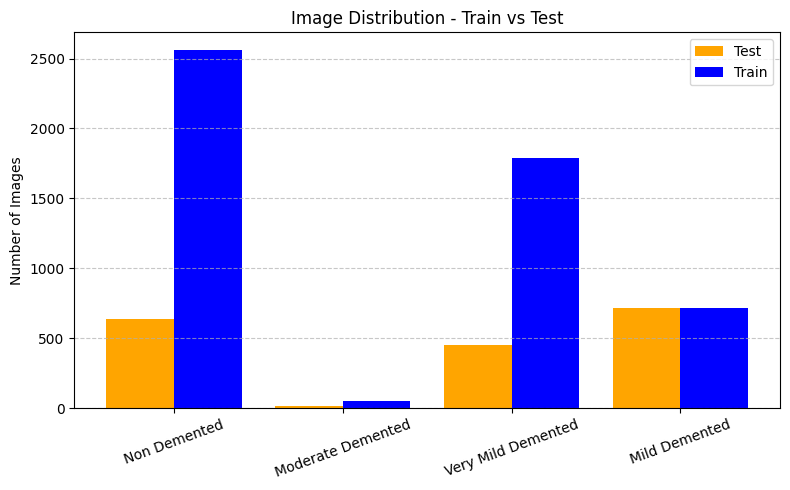

In [ ]:
# Data
categories = ["Non Demented", "Moderate Demented", "Very Mild Demented", "Mild Demented"]

test_counts = [
    len(enhancement_non),
    len(enhancement_moderate),
    len(enhancement_verymild),
    len(enhancement_mildt)
]

train_counts = [
    len(enhancement_nont),
    len(enhancement_moderatet),
    len(enhancement_verymildt),
    len(enhancement_mildt)
]

# Plot setup
plt.figure(figsize=(8,5))
x = range(len(categories))
bar_width = 0.4

# Bars
plt.bar([i - bar_width/2 for i in x], test_counts, width=bar_width, label="Test", color="orange")
plt.bar([i + bar_width/2 for i in x], train_counts, width=bar_width, label="Train", color="blue")

# Labels & Title
plt.xticks(x, categories, rotation=20)
plt.ylabel("Number of Images")
plt.title("Image Distribution - Train vs Test")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show
plt.tight_layout()
plt.show()

In [78]:
# ====== FIND MAX CLASS SIZE ======
max_count = max(len(img_list) for img_list in class_images.values())
output_dir="Pre-processed"
# ====== OVERSAMPLE ======
for cls, img_list in class_images.items():
    cls_output_path = os.path.join(output_dir, cls)
    os.makedirs(cls_output_path, exist_ok=True)

    # Save original images
    for i, img_array in enumerate(img_list):
        img_pil = Image.fromarray(np.uint8(img_array))
        img_pil.save(os.path.join(cls_output_path, f"orig_{i}.jpg"))

    # Augment until reaching max_count
    while len(os.listdir(cls_output_path)) < max_count:
        img_array = random.choice(img_list)
        x = np.expand_dims(img_array, axis=0)

        aug_iter = datagen.flow(x, batch_size=1)
        aug_img = next(aug_iter)[0].astype('uint8')

        aug_filename = f"aug_{len(os.listdir(cls_output_path))}.jpg"
        Image.fromarray(aug_img).save(os.path.join(cls_output_path, aug_filename))

# ====== CHECK COUNTS ======
print("\n✅ AFTER augmentation:")
for cls in class_images.keys():
    print(f"{cls}: {len(os.listdir(os.path.join(output_dir, cls)))} images")

print("\nOversampled dataset saved in:", output_dir)


✅ AFTER augmentation:
NonDemented: 2560 images
ModerateDemented: 2560 images
VeryMildDemented: 2560 images
MildDemented: 2560 images

Oversampled dataset saved in: Pre-processed


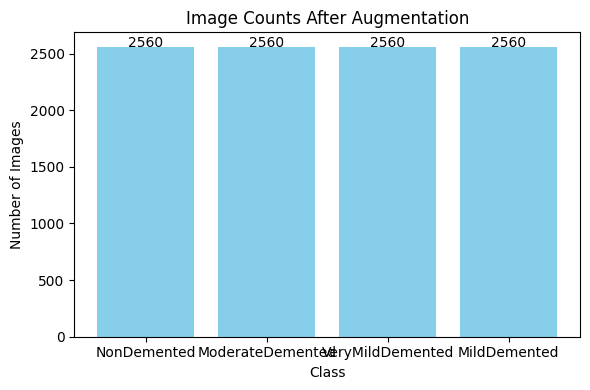

In [73]:
# Plot only after augmentation
counts_after = {cls: len(os.listdir(os.path.join(output_dir, cls))) for cls in class_images.keys()}
plt.figure(figsize=(6, 4))
plt.bar(counts_after.keys(), counts_after.values(), color='skyblue')
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Image Counts After Augmentation")
for i, val in enumerate(counts_after.values()):
    plt.text(i, val + 1, str(val), ha='center', fontsize=10)  # Show count above bar
plt.tight_layout()
plt.show()

### **Test Train Split**

In [3]:
WORK_DIR = './Pre-processed/'

CLASSES = [ 'NonDemented',
            'VeryMildDemented',
            'MildDemented',
            'ModerateDemented']

IMG_SIZE = 176
IMAGE_SIZE = [176, 176]
DIM = (IMG_SIZE, IMG_SIZE)

In [4]:
ZOOM = [.99, 1.01]
BRIGHT_RANGE = [0.8, 1.2]
HORZ_FLIP = True
FILL_MODE = "constant"
DATA_FORMAT = "channels_last"

work_dr = IDG(rescale = 1./255, brightness_range=BRIGHT_RANGE, zoom_range=ZOOM, data_format=DATA_FORMAT, fill_mode=FILL_MODE, horizontal_flip=HORZ_FLIP)

train_data_gen = work_dr.flow_from_directory(directory=WORK_DIR, target_size=DIM, batch_size=10240, shuffle=False)

Found 10240 images belonging to 4 classes.


In [5]:
#Retrieving the data from the ImageDataGenerator iterator
train_data, train_labels = next(train_data_gen)

In [6]:
#Splitting the data into train, test, and validation sets
train_data, test_data, train_labels, test_labels = train_test_split(train_data, train_labels, test_size = 0.2, random_state=42)
train_data, val_data, train_labels, val_labels = train_test_split(train_data, train_labels, test_size = 0.2, random_state=42)
print("Train:", train_data.shape, "Val:", val_data.shape, "Test:", test_data.shape)

Train: (6553, 176, 176, 3) Val: (1639, 176, 176, 3) Test: (2048, 176, 176, 3)


In [7]:
print(f"Training set: {len(train_data)}")
print(f"Validation set: {len(val_data)}")
print(f"Test set: {len(test_data)}")

Training set: 6553
Validation set: 1639
Test set: 2048


### **Parameter Tunning**

In [26]:
import optuna
import tensorflow as tf
from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau

# =====================
# Metrics
# =====================
METRICS = [
    tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
    tf.keras.metrics.AUC(name="auc"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
]

# =====================
# Custom callback
# =====================
class MyCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if logs.get("accuracy") and logs.get("accuracy") > 0.99:
            print("\nReached accuracy threshold! Terminating training.")
            self.model.stop_training = True


# =====================
# Model builder for Optuna
# =====================
def create_model(trial):
    input_shape = (176, 176, 3)
    num_classes = 4

    # Base DenseNet
    base_model = DenseNet169(weights="imagenet", include_top=False, input_shape=input_shape)

    # Freeze all but the last block
    trainable = False
    for layer in base_model.layers:
        if "conv5" in layer.name or "pool5" in layer.name:
            trainable = True
        layer.trainable = trainable

    # Hyperparameters
    dense_units_1 = trial.suggest_categorical("dense_units_1", [512, 1024])
    dense_units_2 = trial.suggest_categorical("dense_units_2", [512, 1024])
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.6)
    optimizer_name = trial.suggest_categorical("optimizer", ["adam", "rmsprop", "sgd"])
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)

    # Architecture
    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = Dropout(dropout_rate)(x)
    x = Flatten()(x)
    x = BatchNormalization()(x)

    x = Dense(dense_units_1)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(dense_units_2)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(dropout_rate)(x)

    outputs = Dense(num_classes, activation="softmax")(x)
    model = Model(inputs=inputs, outputs=outputs, name="densenet169_cnn_model")

    # Optimizer
    if optimizer_name == "adam":
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_name == "rmsprop":
        optimizer = RMSprop(learning_rate=learning_rate)
    else:
        optimizer = SGD(learning_rate=learning_rate, momentum=0.9)

    model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=METRICS)
    return model


# =====================
# Optuna Objective
# =====================
def objective(trial):
    model = create_model(trial)

    callbacks = [
        MyCallback(),
        ReduceLROnPlateau(monitor="val_loss", patience=2)
    ]

    history = model.fit(
        train_data, train_labels,
        validation_data=(val_data, val_labels),
        epochs=2,  # small for fast tuning
        batch_size=trial.suggest_categorical("batch_size", [16, 32, 64]),
        callbacks=callbacks,
        verbose=0
    )

    val_acc = max(history.history["val_accuracy"])
    return val_acc


# =====================
# Run Study
# =====================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5)

print("Best trial:")
trial = study.best_trial
print(trial.params)

c:\Users\Lenovo\Desktop\Jithu Project\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-08-20 01:24:45,935] A new study created in memory with name: no-name-d61d5847-ce53-4fa4-ae8e-cea5ce1297dd
[I 2025-08-20 01:40:54,019] Trial 0 finished with value: 0.5960952043533325 and parameters: {'dense_units_1': 1024, 'dense_units_2': 1024, 'dropout_rate': 0.25810169897853374, 'optimizer': 'sgd', 'learning_rate': 1.7900484907706597e-05, 'batch_size': 32}. Best is trial 0 with value: 0.5960952043533325.
[I 2025-08-20 01:56:45,230] Trial 1 finished with value: 0.7730323076248169 and parameters: {'dense_units_1': 512, 'dense_units_2': 1024, 'dropout_rate': 0.3022068549079554, 'optimizer': 'rmsprop', 'learning_rate': 0.00027964098574895176, 'batch_size': 32}. Best is trial 1 with value: 0.7730323076248169.
[I 2025-08-

Best trial:
{'dense_units_1': 512, 'dense_units_2': 1024, 'dropout_rate': 0.34973210505926317, 'optimizer': 'adam', 'learning_rate': 8.57505716578459e-05, 'batch_size': 32}


### **Model Training -DenseNet169**

In [15]:
# =====================
# DenseNet169 Base Model
# =====================
input_shape = (176, 176, 3)
num_classes = 4

base_model = DenseNet169(
    weights="imagenet",
    include_top=False,
    input_shape=input_shape
)

# Freeze all but the last conv/pooling block
trainable = False
for layer in base_model.layers:
    if "conv5" in layer.name or "pool5" in layer.name:
        trainable = True
    layer.trainable = trainable

print(f"Building DenseNet169 model with {num_classes} output classes")

# =====================
# Custom DenseNet Model
# =====================
inputs = Input(shape=input_shape)
x = base_model(inputs, training=False)

x = Dropout(0.3497)(x)
x = Flatten()(x)
x = BatchNormalization()(x)

x = Dense(512)(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = Dropout(0.2)(x)

x = Dense(1024)(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = Dropout(0.2)(x)

outputs = Dense(num_classes, activation="softmax")(x)
densenet169_model = Model(inputs=inputs, outputs=outputs, name="densenet169_cnn_model")

# =====================
# Custom Callback
# =====================
class MyCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if logs.get("accuracy") and logs.get("accuracy") > 0.99:
            print("\nReached accuracy threshold! Terminating training.")
            self.model.stop_training = True

my_callback = MyCallback()
rop_callback = ReduceLROnPlateau(monitor="val_loss", patience=3)

METRICS = [
    tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
    tf.keras.metrics.AUC(name="auc"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
]

CALLBACKS = [my_callback, rop_callback]

# =====================
# Compile Model
# =====================
densenet169_model.compile(
    optimizer=Adam(learning_rate=8.575e-05),
    loss="categorical_crossentropy",
    metrics=METRICS
)

densenet169_model.summary()

# =====================
# Train Model
# =====================
EPOCHS = 20
history = densenet169_model.fit(
    train_data,
    train_labels,
    validation_data=(val_data, val_labels),
    callbacks=CALLBACKS,
    epochs=EPOCHS
)

Building DenseNet169 model with 4 output classes


Model: "densenet169_cnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 176, 176, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet169 (Functional)        │ (None, 5, 5, 1664)     │    12,642,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 5, 5, 1664)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 41600)          │       166,400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │    21,299,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         4,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,644,548 (132.16 MB)

 Trainable params: 27,832,324 (106.17 MB)

 Non-trainable params: 6,812,224 (25.99 MB)

Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 506s 2s/step - accuracy: 0.5645 - auc: 0.8228 - loss: 1.0060 - precision: 0.6248 - recall: 0.4817 - val_accuracy: 0.7785 - val_auc: 0.9490 - val_loss: 0.5529 - val_precision: 0.8419 - val_recall: 0.6888 - learning_rate: 8.5750e-05
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 450s 2s/step - accuracy: 0.7987 - auc: 0.9598 - loss: 0.4717 - precision: 0.8265 - recall: 0.7624 - val_accuracy: 0.8151 - val_auc: 0.9638 - val_loss: 0.4527 - val_precision: 0.8451 - val_recall: 0.7822 - learning_rate: 8.5750e-05
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 446s 2s/step - accuracy: 0.8954 - auc: 0.9870 - loss: 0.2718 - precision: 0.9063 - recall: 0.8788 - val_accuracy: 0.8426 - val_auc: 0.9722 - val_loss: 0.4020 - val_precision: 0.8595 - val_recall: 0.8212 - learning_rate: 8.5750e-05
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 445s 2s/step - accuracy: 0.9400 - auc: 0.9958 - loss: 0.1555 - precision: 0.9475 - recall: 0.9356 - val_accuracy: 0.8389 - val_auc: 0.9677 - val_lo

In [8]:
from tensorflow.keras.models import load_model
#densenet169_model.save('my_model_2.keras')
densenet169_model = load_model('my_model_2.keras')

c:\Users\Lenovo\Desktop\Jithu Project\env\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 208 variables whereas the saved optimizer has 414 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


### **Model Evaluation**

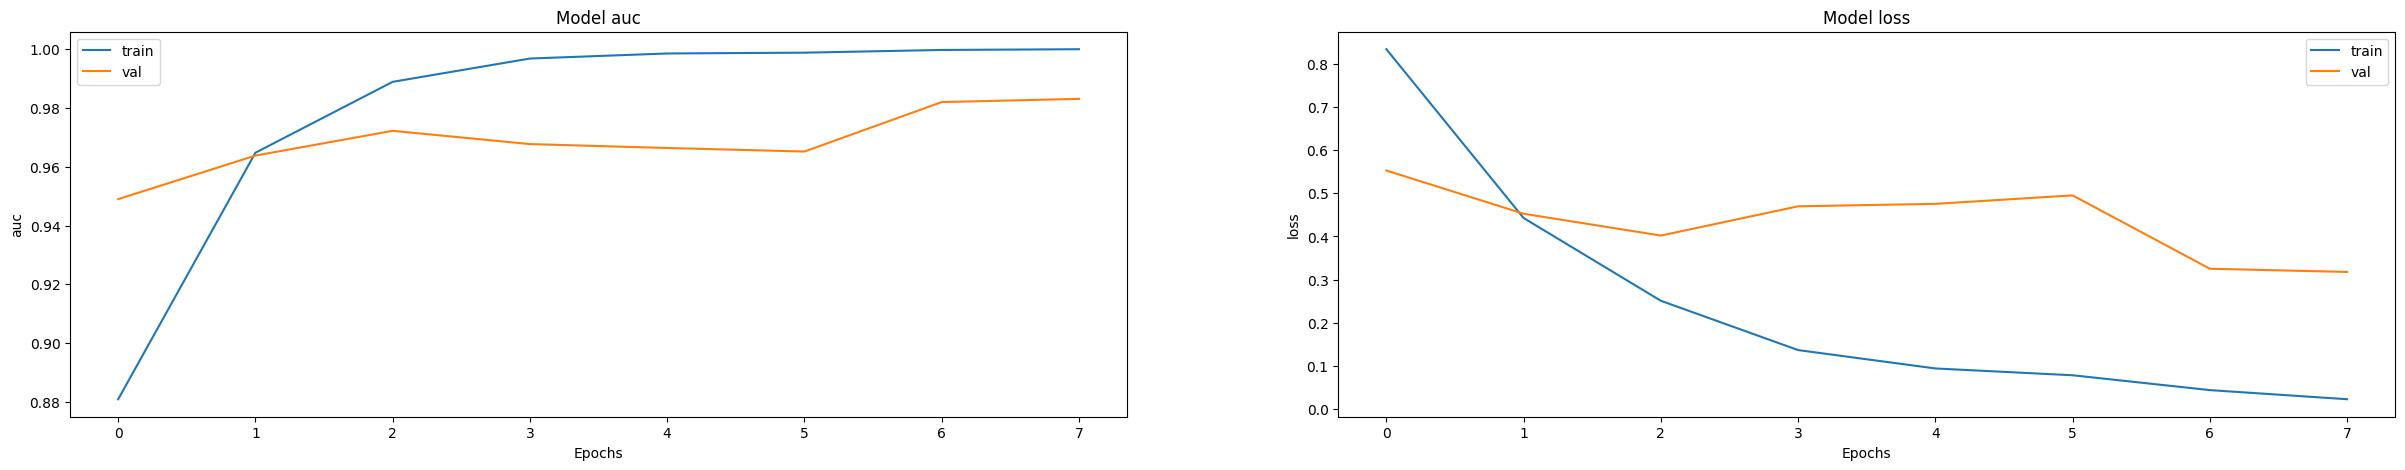

In [17]:
#Plotting the trend of the metrics during training

fig, ax = plt.subplots(1, 2, figsize = (30, 5))
ax = ax.ravel()

for i, metric in enumerate(["auc", "loss"]):
    ax[i].plot(history.history[metric])
    ax[i].plot(history.history["val_" + metric])
    ax[i].set_title("Model {}".format(metric))
    ax[i].set_xlabel("Epochs")
    ax[i].set_ylabel(metric)
    ax[i].legend(["train", "val"])

In [18]:
train_scores = densenet169_model.evaluate(train_data, train_labels)
val_scores = densenet169_model.evaluate(val_data, val_labels)
test_scores = densenet169_model.evaluate(test_data, test_labels)

print("Training Accuracy: %.2f%%"%(train_scores[1] * 100))
print("Validation Accuracy: %.2f%%"%(val_scores[1] * 100))
print("Testing Accuracy: %.2f%%"%(test_scores[1] * 100))

205/205 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.9994 - auc: 1.0000 - loss: 0.0066 - precision: 0.9994 - recall: 0.9994
52/52 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.8957 - auc: 0.9844 - loss: 0.3022 - precision: 0.9019 - recall: 0.8897
64/64 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.8595 - auc: 0.9732 - loss: 0.4322 - precision: 0.8644 - recall: 0.8554
Training Accuracy: 99.91%
Validation Accuracy: 89.44%
Testing Accuracy: 86.77%


In [19]:
#Predicting the test data
pred_labels = densenet169_model.predict(test_data)

64/64 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step


In [20]:
def roundoff(arr):
    """To round off according to the argmax of each predicted label array. """
    arr[np.argwhere(arr != arr.max())] = 0
    arr[np.argwhere(arr == arr.max())] = 1
    return arr
for labels in pred_labels:
    labels = roundoff(labels)
print(classification_report(test_labels, pred_labels, target_names=CLASSES))

                  precision    recall  f1-score   support

     NonDemented       0.86      0.88      0.87       523
VeryMildDemented       0.98      1.00      0.99       527
    MildDemented       0.80      0.91      0.85       472
ModerateDemented       0.83      0.69      0.75       526

       micro avg       0.87      0.87      0.87      2048
       macro avg       0.87      0.87      0.86      2048
    weighted avg       0.87      0.87      0.87      2048
     samples avg       0.87      0.87      0.87      2048



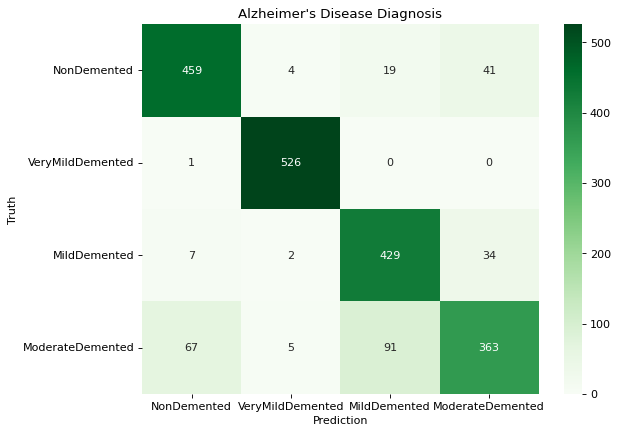

In [21]:
#Plot the confusion matrix to understand the classification in detail

pred_ls = np.argmax(pred_labels, axis=1)
test_ls = np.argmax(test_labels, axis=1)

conf_arr = confusion_matrix(test_ls, pred_ls)

plt.figure(figsize=(8, 6), dpi=80, facecolor='w', edgecolor='k')

ax = sns.heatmap(conf_arr, cmap='Greens', annot=True, fmt='d', xticklabels= CLASSES,
                yticklabels=CLASSES)

plt.title('Alzheimer\'s Disease Diagnosis')
plt.xlabel('Prediction')
plt.ylabel('Truth')
plt.show(ax)

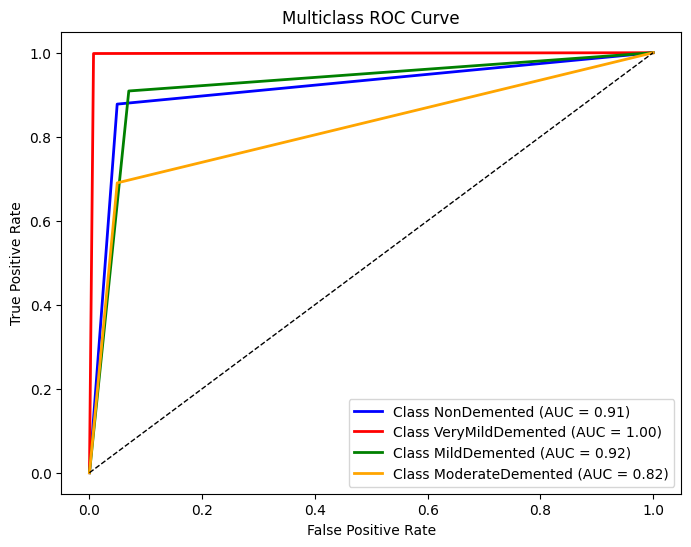

In [22]:
from sklearn.metrics import roc_curve, auc
from itertools import cycle
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(4):
    fpr[i], tpr[i], _ = roc_curve(test_labels[:, i], pred_labels[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
class_dict = {0:'NonDemented', 1:'VeryMildDemented', 2:'MildDemented', 3:'ModerateDemented'}
# Plot ROC curves
plt.figure(figsize=(8, 6))
colors = cycle(["blue", "red", "green", "orange"])
for i, color in zip(range(4), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f"Class {class_dict[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend(loc="lower right")
plt.show()